<a href="https://colab.research.google.com/github/fathimaa-afreen/ADD_ON_COURSE/blob/main/Day3_cat_dog_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!unzip /content/animals.zip -d /content

Archive:  /content/animals.zip
   creating: /content/animal/
   creating: /content/animal/cats/
  inflating: /content/animal/cats/pexels-724211268-34345889.jpg  
  inflating: /content/animal/cats/pexels-ahcapture-29817799.jpg  
  inflating: /content/animal/cats/pexels-ayushs120-32727346.jpg  
  inflating: /content/animal/cats/pexels-lord_-photon-27537-116835.jpg  
  inflating: /content/animal/cats/pexels-marwan-benjamin-622158651-20338832.jpg  
  inflating: /content/animal/cats/pexels-mati-4734723 (1).jpg  
  inflating: /content/animal/cats/pexels-mati-4734723.jpg  
  inflating: /content/animal/cats/pexels-neodc-16412582.jpg  
  inflating: /content/animal/cats/pexels-orhanbaysal-31363657.jpg  
  inflating: /content/animal/cats/pexels-takamine-30840928.jpg  
   creating: /content/animal/dogs/
  inflating: /content/animal/dogs/pexels-christina-brik-376396559-14555660.jpg  
  inflating: /content/animal/dogs/pexels-dishank-sheth-2162353322-38221522.jpg  
  inflating: /content/animal/dogs/p

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

### Loading and Preprocessing Images

I will now load the images from the `/content/animal/cats` and `/content/animal/dogs` directories. For each image, I will resize it to 224x224 pixels and assign a label: 0 for cats and 1 for dogs. The processed images and their labels will be stored in `images` and `labels` lists, respectively.

In [ ]:
base_image_folder = "/content/animal"

images = []  # This list will store the image data.
labels = []  # This list stores the class of each image. (cat=0, dog=1)

for animal_type in ['cats', 'dogs']:
    current_folder = os.path.join(base_image_folder, animal_type)
    print(f"\nProcessing images from: {current_folder}")
    for filename in os.listdir(current_folder):
        if filename.endswith((".jpg", ".png", ".jpeg")):
            img_path = os.path.join(current_folder, filename)  # Complete path

            img = cv2.imread(img_path)      # Read the image
            if img is None:
                print(f"Warning: Could not read image {img_path}. Skipping.")
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (224,224))

            images.append(img)  # Store the processed image

            # Label creation
            if animal_type == 'cats':
                labels.append(0)      # Cat
                # print(filename, "-> Label: 0 (Cat)")

            elif animal_type == 'dogs':
                labels.append(1)      # Dog
                # print(filename, "-> Label: 1 (Dog)")

print("\nAll images processed.")

# Convert lists to numpy arrays for easier manipulation
images = np.array(images)
labels = np.array(labels)

print(f"Shape of images array: {images.shape}")
print(f"Shape of labels array: {labels.shape}")


Processing images from: /content/animal/cats

Processing images from: /content/animal/dogs

All images processed.
Shape of images array: (20, 224, 224, 3)
Shape of labels array: (20,)


In [ ]:
print("Total Images:", len(images))
print("Total Labels:", len(labels))

Total Images: 20
Total Labels: 20


In [ ]:
#convert to numpy arrays(list to array)
X = np.array(images)
y = np.array(labels)

print(X.shape)
print(y)

(20, 224, 224, 3)
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]


In [ ]:
X = X / 255.0

In [ ]:
X = X.reshape(20, -1)

In [ ]:
print(X.shape)

(20, 150528)


In [ ]:
#train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB() #create the model
model.fit(X_train, y_train)#trains the model with the data that is given above

GaussianNB()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)#find accuracy from the actual and the predicted
print("Accuracy:", accuracy)

Accuracy: 0.5


In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

In [ ]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.75


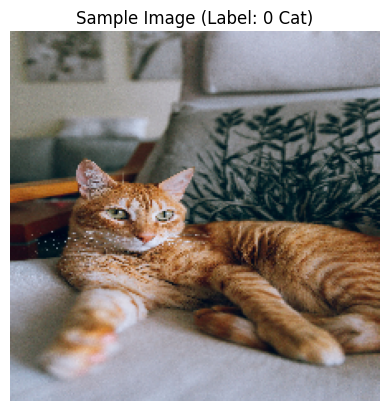

In [ ]:
# Display the first image from the 'images' array
plt.imshow(images[0])
plt.title(f"Sample Image (Label: {labels[0]} {'Cat' if labels[0] == 0 else 'Dog'})")
plt.axis("off")
plt.show()

In [ ]:
# Prepare the first image for prediction
img_to_predict = images[0]
img_to_predict = img_to_predict / 255.0  # Normalize
img_to_predict = img_to_predict.reshape(1, -1) # Flatten

# Assign to 'img' variable to be used by subsequent prediction cells
img = img_to_predict

In [ ]:
prediction = model.predict(img)
print("Prediction:", prediction)

Prediction: [0]


In [ ]:
if prediction[0] == 0:
    print("Cat")
else:
    print("Dog")

Cat
